In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from collections import namedtuple
from tqdm.notebook import trange

In [10]:
############################
#### Physical constants ####
############################
PhysicalConstants = namedtuple('PhysicalConstants', ('g', 'rho_w', 'nu'))
CONST = PhysicalConstants(g=9.81,      # Acceleration due to gravity (m/s**2)
                          rho_w=1025,  # Density of sea water (kg/m**3)
                          nu=1.358e-6, # Kinematic viscosity of sea water (m**2/s)
                         )

def rise_speed(d, rho):
    '''
    Calculate the rise speed (m/s) of a droplet due to buoyancy.
    This scheme uses Stokes' law at small Reynolds numbers, with
    a harmonic transition to a constant drag coefficient at high
    Reynolds numbers.
    
    See Johansen (2000), Eq. (14) for details.
    
    d: droplet diameter (m)
    rho: droplet density (kg/m**3)
    '''
    # Physical constants
    pref  = 1.054       # Numerical prefactor
    nu    = CONST.nu    # Kinematic viscosity of seawater (m**2/s)
    rho_w = CONST.rho_w # Density of seawater (kg/m**3)
    g = CONST.g         # Acceleration of gravity (m/s**2)
    
    g_    = g*(rho_w - rho) / rho_w
    
    w1    = d**2 * g_ / (18*nu)
    w2    = np.sqrt(d*abs(g_)) * pref * (g_/np.abs(g_)) # Last bracket sets sign

    return np.where(g_ == 0, 0.0, w1*w2/(w1+w2))

# Functions for particle transport

In [59]:
def randomstep(Z, K, dt):
    dW = np.random.normal(loc=0, scale=np.sqrt(dt), size=len(Z))
    dz = 1e-3
    dKdz = (K(Z+dz) - K(Z)) / dz
    return Z + dKdz*dt + np.sqrt(2*K(Z)) * dW

def reflect(Z, floor):
    # Reflect about surface
    Z = -np.abs(Z)
    # Reflect about floor
    Z = np.where(Z < floor, 2*floor - Z, Z)
    return Z

def rise(Z, V, dt):
    return Z + V*dt

def surface(Z):
    return np.minimum(Z, 0)

def settle(Z, V, weights, floor):
    # keep those elements where Z is greater than the depth
    # (depth is negative downwards)
    mask = Z > floor
    return Z[mask], V[mask], weights[mask]

def run_experiment(Z, V, Tmax, dt, K, mass=None, n=None, floor=-200):
    Nt = int(Tmax/dt)
    bins, dz = np.linspace(floor, 0, 401, retstep=True)
    mids = bins[:-1] + (bins[1] - bins[0]) / 2
    concentrations = []
    weights = n*mass
    t = 0
    for n in trange(Nt):
        # Displace randomly
        Z = randomstep(Z, K, dt)
        # Reflect about surface and floor
        Z = reflect(Z, floor=floor)
        # Rise due to buoyancy
        Z = rise(Z, V, dt)
        # Stop rise at surface and floor
        Z = surface(Z)
        Z, V, weights = settle(Z, V, weights, floor)
        # Calculate concentrations every hour
        if t % 3600 == 0:
            C, _ = np.histogram(Z, bins=bins, weights=weights)
            concentrations.append(C)
        t += dt
    return Z, concentrations, mids

# Define diffusivity function
def K(z):
    K0, K1, a, b, z0 = [1e-6, 1.9815e-03, 7.28335e-12, 8.16504e+00, 6.24258e+00]
    return K0 + (-z+z0)*K1*np.exp(-(a*(-z+z0)**b))

In [49]:
# Obtain particle size and density distributions

# Wall thickness
h = 1.02e-6
# Glass density
rho_glass = 2230 # kg / m3
# Water density
rho_water = 1025 # kg / m3
# Number of samples
Np = 1000000

# Fitted parameters from top of the notebook, hard-coded here to avoid having to run the whole notebook
w1, s1, scale1, w2, s2, scale2 = [5.57731645e+02, 3.99316702e-01, 6.83270903e+01, 1.00590198e+02, 6.74913778e-01, 3.15483906e+01]
# Normalise weights to find number of samples from each distribution
N1 = int(Np * w1/(w1+w2))
N2 = Np - N1
# Create pdfs
p1 = lognorm(s=s1, scale=scale1)
p2 = lognorm(s=s2, scale=scale2)
# Draw sizes and rescale to m
d = 1e-6 * np.concatenate((p1.rvs(size=N1), p2.rvs(size=N2)))
# volume as function of size
vol = (4/3)*np.pi*(d/2)**3

# Calculate weights to go from volume to number distribution
n = 1 / vol

# Mass of intact spheres
# For spheres with r > h, assume hollow glass shell
M1 = rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*((d-2*h)/2)**3)
# For spheres with r <= h, assume solid glass sphere
M2 = rho_glass *  (4/3)*np.pi*(d/2)**3
# Combine with where
M_intact = np.where(d/2 > h, M1, M2)

# Mass of cracked spheres
# For spheres with r > h, assume hollow glass shell
M1 = rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*((d-2*h)/2)**3) + rho_water * (4/3)*np.pi*((d-2*h)/2)**3
# For spheres with r <= h, assume solid glass sphere
M2 = rho_glass *  (4/3)*np.pi*(d/2)**3
# Combine with where
M_cracked = np.where(d/2 > h, M1, M2)

# Fraction of cracked spheres (fraction of drawn sizes)
xf = 0.765
intact = np.random.random(size=Np) < xf
M_joint = np.where(intact, M_intact, M_cracked)

# Density for each sphere
rho_intact = M_intact / vol
rho_joint = M_joint / vol

# Rise velocities (remains constant for each particle)
V = rise_speed(d, rho_joint)

In [68]:
# Simulation time
Tmax = 30*24*3600
dt = 120

# Find second derivative of K to check timestep
# according to criterion of Visser (1997)
# https://doi.org/10.3354/meps158275
zc, dz = np.linspace(-40, 0, 1000, retstep=True)
ddKddz = (K(zc[2:]) - 2*K(zc[1:-1]) + K(zc[:-2])) / dz**2
print('Timestep should be dt <<', np.amin(1/np.maximum(np.abs(ddKddz), 1e-5)))
print('Timestep is        dt = ', dt)

# Initial depth at surface
Z0 = np.zeros(Np)

# Run simulation
Z, C, mids = run_experiment(Z0, V, Tmax, dt, K, mass=M_intact, n=1/vol)

Timestep should be dt << 689.5789847474495
Timestep is        dt =  120


  0%|          | 0/21600 [00:00<?, ?it/s]

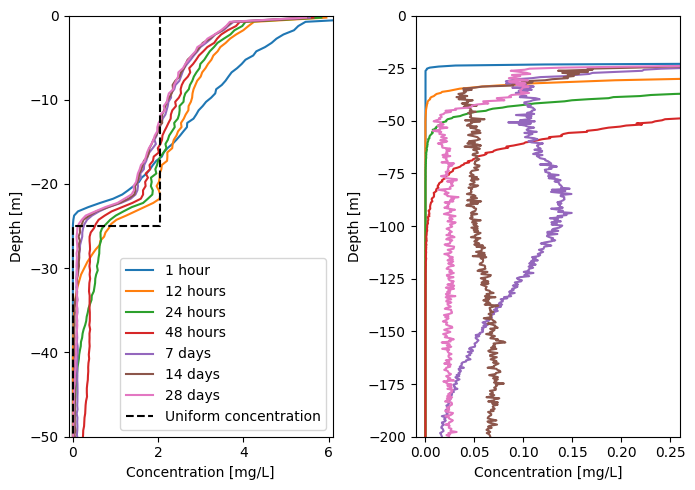

In [70]:
fig, ax = plt.subplots(ncols=2, figsize=(7,5))

# Calculate factor to normalise integral to 1
# (calculated for initial timestep with all particles still in system)
dz = mids[1] - mids[0]
prefac = 1 / np.sum(dz*C[0])
# Multiply with mass per area to get mass per volume
M_area = 70 # g/m2

for i in [1, 12, 24, 48, 7*24, 24*14, 24*28]:
    if i == 1:
        label = '1 hour'
    elif i <= 48:
        label=f'{i} hours'
    else:
        label=f'{int(i/24)} days'
    ax[0].plot(prefac*M_area*C[i], mids, label=label)
    ax[1].plot(prefac*M_area*C[i], mids, label=label)

C_const = 70 * 0.73 / 25
ax[0].plot([C_const, C_const, 0, 0], [0, -25, -25, -50], '--', c='k', label='Uniform concentration')

ax[0].legend(loc='lower right')
ax[0].set_ylim(-50, 0)
ax[0].set_xlim(-0.1, 6.1)
ax[1].set_ylim(-200, 0)
ax[1].set_xlim(-0.01, 0.26)

for a in ax:
    a.set_xlabel('Concentration [mg/L]')
    a.set_ylabel('Depth [m]')

plt.tight_layout()